# Color, Layout, and Accessibility

When you share a chart, you are asking for someone's cognitive energy. If they have to squint to read the text, struggle to tell the difference between two colors, or guess what the main takeaway is, you have lost them. 

Great visual design relies on three pillars:
1. **Strategic Color**: Using the right type of palette for the right type of data.
2. **Accessibility**: Ensuring your charts can be read by people with color vision deficiencies (color blindness).
3. **Layout & Gestalt**: Using whitespace and alignment to group related information automatically in the viewer's brain.

Let's set up a Python sandbox to see how these principles change the way we communicate.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a dataset for a global retail company
np.random.seed(42)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

df = pd.DataFrame({
    'Month': months * 3,
    'Product_Line': ['Electronics']*6 + ['Clothing']*6 + ['Home Goods']*6,
    'Profit': np.random.randint(-20, 100, 18),
    'Satisfaction_Score': np.random.uniform(2.5, 5.0, 18)
})

sns.set_theme(style="white")
print("✅ Retail Dataset loaded!")

✅ Retail Dataset loaded!


# 1. The Three Types of Color Palettes
You should never pick a color palette just because it "looks pretty." You must choose a palette that matches the mathematical nature of your data. 

1. **Qualitative (Categorical)**: For distinct groups with no inherent order (e.g., Countries, Product Lines). Use distinct, unrelated colors.
2. **Sequential**: For numbers moving from low to high (e.g., Age, Sales Volume). Use a single color fading from light to dark.
3. **Diverging**: For numbers with a critical midpoint (e.g., Profit/Loss, Temperature). Use two contrasting colors that fade into a neutral white/gray in the middle.

/tmp/ipykernel_10921/4171204824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df[df['Month']=='Jan'], x='Product_Line', y='Profit', palette='Set2')
/tmp/ipykernel_10921/4171204824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=sorted_df, x='Product_Line', y='Satisfaction_Score', palette='Blues')
/tmp/ipykernel_10921/4171204824.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=df[df['Month']=='Feb'], x='Product_Line', y='Profit', palette=colors)


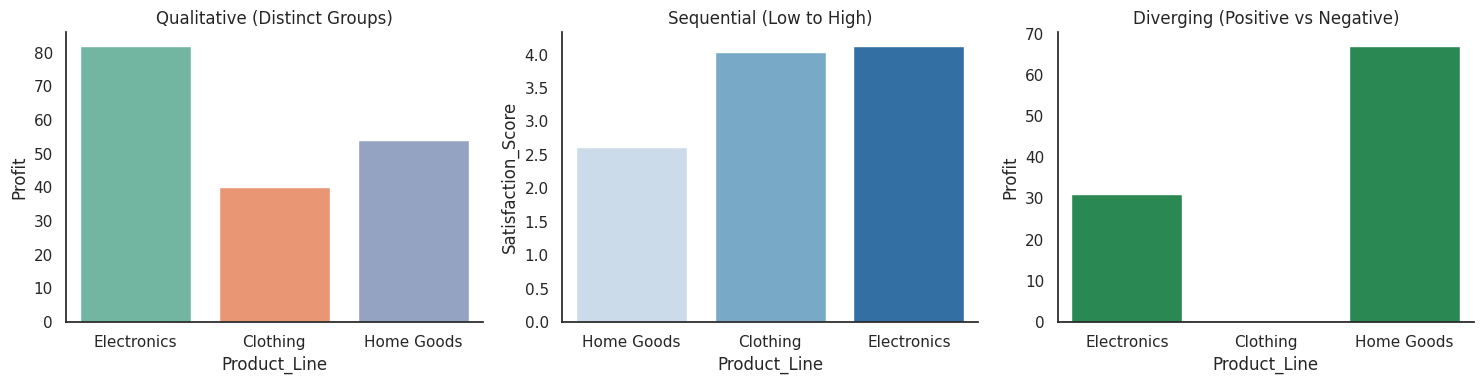

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. QUALITATIVE: Product Lines (No order, distinct colors)
sns.barplot(ax=axes[0], data=df[df['Month']=='Jan'], x='Product_Line', y='Profit', palette='Set2')
axes[0].set_title('Qualitative (Distinct Groups)')

# 2. SEQUENTIAL: Satisfaction Score (Low to High, light to dark)
# We sort the data so the gradient makes visual sense
sorted_df = df[df['Month']=='Jan'].sort_values('Satisfaction_Score')
sns.barplot(ax=axes[1], data=sorted_df, x='Product_Line', y='Satisfaction_Score', palette='Blues')
axes[1].set_title('Sequential (Low to High)')

# 3. DIVERGING: Profit and Loss (Zero is a critical midpoint)
# We create a custom palette: Red for negative, Green for positive
colors = ['#d73027' if p < 0 else '#1a9850' for p in df[df['Month']=='Feb']['Profit']]
sns.barplot(ax=axes[2], data=df[df['Month']=='Feb'], x='Product_Line', y='Profit', palette=colors)
axes[2].set_title('Diverging (Positive vs Negative)')
axes[2].axhline(0, color='black', linewidth=1) # Draw the zero line

sns.despine()
plt.tight_layout()
plt.show()

# 2. Designing for Accessibility (Color Blindness)
Approximately 8% of men and 0.5% of women have some form of color vision deficiency (CVD). The most common is **Red-Green color blindness** (Deuteranomaly). 

If you make a chart where "Good" is Green and "Bad" is Red, nearly 1 in 12 men in your boardroom will just see two identical shades of muddy brown. 

**The Golden Rule:** Never rely on color *alone* to convey meaning. 

/tmp/ipykernel_10921/2989111267.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=compare_df, x='Month', y='Profit', palette=['#ff0000', '#00ff00'])
/tmp/ipykernel_10921/2989111267.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=compare_df, x='Month', y='Profit', palette='colorblind')
/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu 

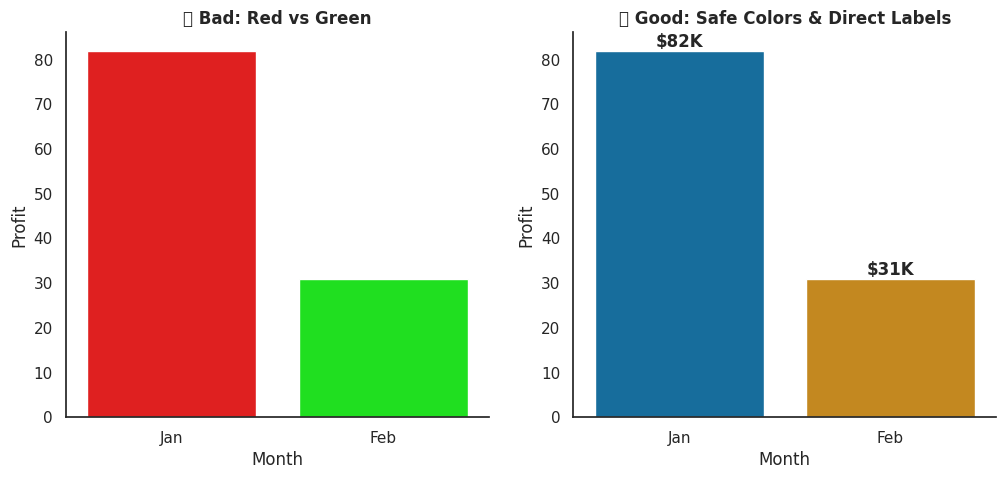

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Filter data for a quick comparison
compare_df = df[(df['Month'].isin(['Jan', 'Feb'])) & (df['Product_Line'] == 'Electronics')]

# ❌ THE INACCESSIBLE CHART ❌
# Relies entirely on Red vs Green. A colorblind person cannot read this.
sns.barplot(ax=axes[0], data=compare_df, x='Month', y='Profit', palette=['#ff0000', '#00ff00'])
axes[0].set_title('❌ Bad: Red vs Green', fontweight='bold')

# ✅ THE ACCESSIBLE CHART ✅
# 1. Use a colorblind-friendly palette (like Seaborn's 'colorblind' or matplotlib's 'viridis')
# 2. Add direct text labels so color isn't the only indicator!
sns.barplot(ax=axes[1], data=compare_df, x='Month', y='Profit', palette='colorblind')
axes[1].set_title('✅ Good: Safe Colors & Direct Labels', fontweight='bold')

# Adding the direct text labels
for p in axes[1].patches:
    axes[1].annotate(f"${int(p.get_height())}K", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')

sns.despine()
plt.show()

# 3. Layout and the Gestalt Principle of Proximity
**Gestalt psychology** tells us how the human brain automatically groups visual elements. The most powerful principle is **Proximity**: *Things that are close together are perceived as belonging together.*

If your chart title is too far away from the data, or if your legend is shoved into a weird corner, the viewer's brain has to work overtime to connect them.

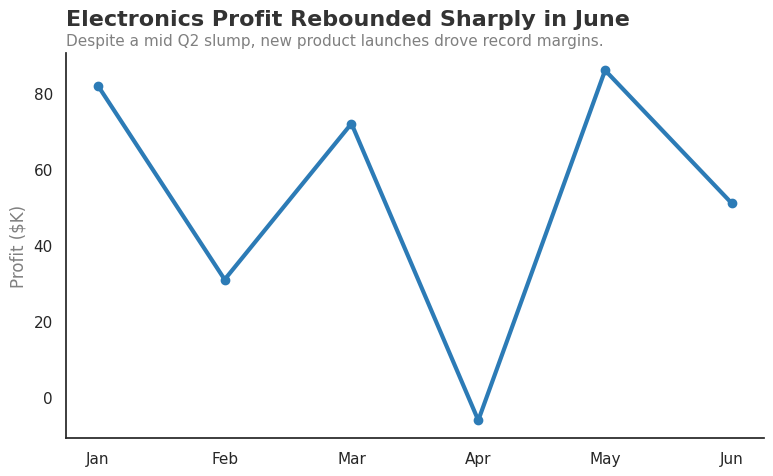

In [4]:
# ✅ THE PERFECT LAYOUT ✅
# We use whitespace, alignment, and proximity to guide the eye seamlessly.

plt.figure(figsize=(9, 5))

# Plot the trend of Electronics over time
elec_df = df[df['Product_Line'] == 'Electronics']
plt.plot(elec_df['Month'], elec_df['Profit'], marker='o', linewidth=3, color='#2c7bb6')

# 1. Alignment & Proximity: Left-align the title directly over the start of the data
plt.title("Electronics Profit Rebounded Sharply in June", 
          fontsize=16, fontweight='bold', color='#333333', loc='left', pad=20)

# 2. Subtitle for context (placed directly under the title)
plt.suptitle("Despite a mid Q2 slump, new product launches drove record margins.", 
             fontsize=11, color='gray', x=0.125, y=0.92, ha='left')

# 3. Highlight the key takeaway (June) with an annotation
# Instead of a separate legend, we put the text right next to the data!
plt.annotate('Record High:\n$95K', 
             xy=(5, 95), xytext=(4.5, 70), # Point to June (index 5)
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', color='#2c7bb6')

# Clean up the axes
plt.ylabel("Profit ($K)", color='gray')
plt.xlabel("") # Months are obvious, no need to write "Month"
sns.despine()

plt.show()

*(Notice how your eye reads this chart: First, the bold title tells you what happened. Then the gray subtitle gives you the "why". Finally, your eye is naturally drawn down to the blue line, ending at the explicit annotation pointing to the record high. You just controlled the viewer's brain using layout!)*

## Real-World Use Case or Analogy:
Think of Color, Layout, and Accessibility like designing **Wayfinding Signs in a Hospital**:

* **Color Theory**: You don't paint the Emergency Room signs a relaxing, sequential pastel blue. You paint them a stark, diverging Red or Yellow because you need them to trigger immediate psychological urgency. 
* **Accessibility**: If the hospital loses power and goes to emergency lighting, or if a patient forgot their glasses, can they still find the exit? You can't just rely on a red background; you need the explicit word "EXIT" printed in high-contrast, bold, easily readable letters.
* **Layout (Gestalt Proximity)**: If an arrow points left, the word "Cardiology" needs to be printed directly next to that arrow. If the arrow is on the left wall and the word "Cardiology" is on the right wall, patients will get lost in the hallway. Related information must live together visually.

---